# <span style="color:green"> Numerical Simulation Laboratory </span>
## <span style="color:brown"> Python Exercise 12 </span>
## <span style="color:orange"> Keras - Deep & Convolutional Neural Network image recognition </span>
### MNIST with Keras

The goal of exercise 12 is to use deep neural network models, implemented in the Keras python package, to recognize and distinguish between the ten handwritten digits (0-9).

The MNIST dataset comprises $70000$ handwritten digits, each of which comes in a square image, divided into a $28\times 28$ pixel grid. Every pixel can take on $256$ gradation of the gray color, interpolating between white and black, and hence each data point assumes any value in the set $\{0,1,\dots,255\}$. Since there are $10$ categories in the problem, corresponding to the ten digits, this problem represents a generic **classification task**. 

In [14]:
#import os
#os.environ['KMP_DUPLICATE_LIB_OK']='True' #This is needed in my Anaconda+MacOsX installation; leave it commented.
import tensorflow as tf
from tensorflow import keras
import os
import numpy as np
import matplotlib.pyplot as plt
seed=0
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

## Building a Deep Neural Network (DNN) in 5 Steps

1. **Load and preprocess the data**  
   - Flatten 28×28 images into 784-element vectors (Dense layers need 1D input).  
   - Normalize pixel values to [0,1].  
   - Convert integer labels to one-hot vectors.  
   - **Implemented in:** `preprocess_mnist_data()`  

2. **Define the architecture**  
   - Create a `Sequential` model.  
   - Add Dense layers with ReLU activation (optionally Dropout).  
   - Output layer: 10 neurons (digits 0–9), activation = softmax.  
   - **Implemented in:** `create_DNN()`  

3. **Compile the model**  
   - Loss: `categorical_crossentropy` (compares predicted probability distribution with true one-hot vector).  
   - Optimizer: SGD, Adam, etc.  
   - Metric: `accuracy`.  
   - **Implemented in:** `compile_model()`  

4. **Train the model**  
   - Use `model.fit` with training data.  
   - Set epochs, batch size, shuffle, and validation data.  
   - **Implemented in:** `compile_fit_model()`  

5. **Evaluate and test**  
   - Compute accuracy and loss on test set (`model.evaluate`).  
   - Plot accuracy/loss vs epochs.  
   - Show predictions vs true labels.  
   - **Implemented in:** `plot_training_history_and_predictions()` 

In [26]:
#----STEP 1 ----- 
## LOAD DATA
from keras.datasets import mnist

# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 # 10 digits

# the data, split between train and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)

## RESHAPE DATA AND CONVERT LABELS 
def preprocess_mnist_data(X_train, Y_train, X_test, Y_test, img_rows=28, img_cols=28, num_classes=10):
    """
    Preprocessa i dati MNIST per l'uso in modelli con categorical_crossentropy:
    - reshape da immagini a vettori (28x28 -> 784)
    - cast a float32
    - normalizzazione tra 0 e 1
    - conversione etichette in one-hot encoding

    Restituisce:
    ---------
    X_train, Y_train, X_test, Y_test : array preprocessati
    """

    # Reshape: immagini (28x28) a vettori (784,)
    x_train = X_train.reshape(X_train.shape[0], img_rows * img_cols)
    x_test = X_test.reshape(X_test.shape[0], img_rows * img_cols)

    # Cast a float32 e normalizza
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0

    # One-hot encoding
    y_train = keras.utils.to_categorical(Y_train, num_classes)
    y_test = keras.utils.to_categorical(Y_test, num_classes)

    
    

    print('x_train shape:', x_train.shape)
    print('y_train shape:', y_train.shape)  
    print('x_test shape:', x_test.shape)
    print('y_test shape:', y_test.shape)

    return x_train, y_train, x_test, y_test

#-----END STEP 1------



#---STEP 2--- define neural net and its Architecture
from keras.models import Sequential
from keras.layers import Dense, Dropout

def create_DNN():
    # instantiate model
    model = Sequential()
    # add a dense all-to-all relu layer
    model.add(Dense(400,input_shape=(img_rows*img_cols,), activation='relu'))
    # add a dense all-to-all relu layer
    model.add(Dense(100, activation='relu'))
    # apply dropout with rate 0.5
    model.add(Dropout(0.5))
    # soft-max layer
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

print('Model architecture created successfully!')

#---END STEP 2----------

#----STEP 3--- Choose the Optimizer and the Cost Function
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam

def compile_model(optimizer=SGD()):
    # create the model
    model=create_DNN()
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=optimizer,
                  metrics=['acc'])

    print('Model compiled successfully and ready to be trained.')

    return model



#----STEP 4--
def compile_fit_model(X_train, Y_train,X_test, Y_test,optimizer=SGD(),epochs=30,batch_size=32):
    # create the deep neural net
    model_DNN = compile_model(optimizer)

    # train DNN and store training info in history
    history = model_DNN.fit(X_train, Y_train,
            batch_size=batch_size,
            epochs=epochs,
            verbose=0,
            validation_data=(X_test, Y_test))

    print('Model trained successfully.')

    return model_DNN, history



def plot_training_history_and_predictions(history, model, X_test, Y_test, img_rows, img_cols,optimazer):
    """
    Plotta l'andamento di accuracy e loss durante il training e visualizza le predizioni su 10 immagini di test.

    Parametri:
    -----------
    history : keras.callbacks.History
        Oggetto restituito da model.fit(), contenente 'acc', 'val_acc', 'loss', 'val_loss'.

    model : keras.Model
        Modello addestrato usato per effettuare le predizioni.

    X_test : numpy.ndarray
        Immagini di test (prima del reshape finale se necessario).

    Y_test : numpy.ndarray
        Etichette one-hot delle immagini di test.

    img_rows : int
        Altezza delle immagini.

    img_cols : int
        Larghezza delle immagini.

    """ #----STEP 5--------
    # 
    score = model.evaluate(X_test, Y_test, verbose=1)

    # print performance
    print()
    print('Test loss:', score[0])
    print('Test accuracy:', score[1])


    # Estrai metriche dal training
    acc = history.history.get('acc') or history.history.get('accuracy')
    val_acc = history.history.get('val_acc') or history.history.get('val_accuracy')
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)

    # Plot: Accuracy & Loss
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].plot(epochs, acc, label='Train')
    axs[0].plot(epochs, val_acc, label='Validation')
    axs[0].set_title(f'Model Accuracy-{optimazer}')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend(loc='best')

    axs[1].plot(epochs, loss, label='Train')
    axs[1].plot(epochs, val_loss, label='Validation')
    axs[1].set_title(f'Model Loss-{optimazer}')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].legend(loc='best')

    plt.tight_layout()
    plt.show()

   

    # Predizioni su X_test
    predictions = model.predict(X_test.reshape(X_test.shape[0], img_rows * img_cols))  # Flatten input se necessario
    X_test_reshaped = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)

    # Visualizza le prime 10 predizioni
    plt.figure(figsize=(20, 5))
    for i in range(10):
        ax = plt.subplot(2, 10, i + 1)
        plt.imshow(X_test_reshaped[i, :, :, 0], cmap='gray')
        plt.title(f"Digit: {np.argmax(Y_test[i])}\nPredicted: {np.argmax(predictions[i])}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

X_train shape: (60000, 28, 28)
Y_train shape: (60000,)
Model architecture created successfully!


## Optimizers used

- **SGD (Stochastic Gradient Descent)**  
  Updates weights using gradients computed on mini-batches; simple and reliable but may converge slowly without momentum or learning rate tuning.  

- **Adam (Adaptive Moment Estimation)**  
  Combines momentum and adaptive learning rates; fast convergence and widely used as a default optimizer in deep learning.  

- **Adagrad (Adaptive Gradient Algorithm)**  
  Adjusts the learning rate for each parameter based on past gradients; good for sparse data but learning rate can shrink too much over time. 

In [28]:
x_train, y_train, x_test, y_test=preprocess_mnist_data(X_train, Y_train, X_test, Y_test)
models_DNN=[]
histories_DNN=[]
#SGD
model_DNN_sgd,history_sgd= compile_fit_model(x_train, y_train,x_test, y_test,optimizer=SGD(),epochs=15,batch_size=32)
models_DNN.append(model_DNN_sgd)
histories_DNN.append(history_sgd)
#ADAM
model_DNN_adam,history_adam= compile_fit_model(x_train, y_train,x_test, y_test,optimizer=Adam(learning_rate=1e-4),epochs=15,batch_size=32)
models_DNN.append(model_DNN_adam)
histories_DNN.append(history_adam)
#ADAGRAD
model_DNN_adagrad,history_adagrad= compile_fit_model(x_train, y_train,x_test, y_test,optimizer=Adagrad(),epochs=15,batch_size=32)
models_DNN.append(model_DNN_adagrad)
histories_DNN.append(history_adagrad)




x_train shape: (60000, 784)
y_train shape: (60000, 10)
x_test shape: (10000, 784)
y_test shape: (10000, 10)
Model compiled successfully and ready to be trained.
Model trained successfully.
Model compiled successfully and ready to be trained.
Model trained successfully.
Model compiled successfully and ready to be trained.
Model trained successfully.


Training completed for SGD, Adam and Adagrad
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.9680 - loss: 0.1054

Test loss: 0.089680515229702
Test accuracy: 0.9726999998092651


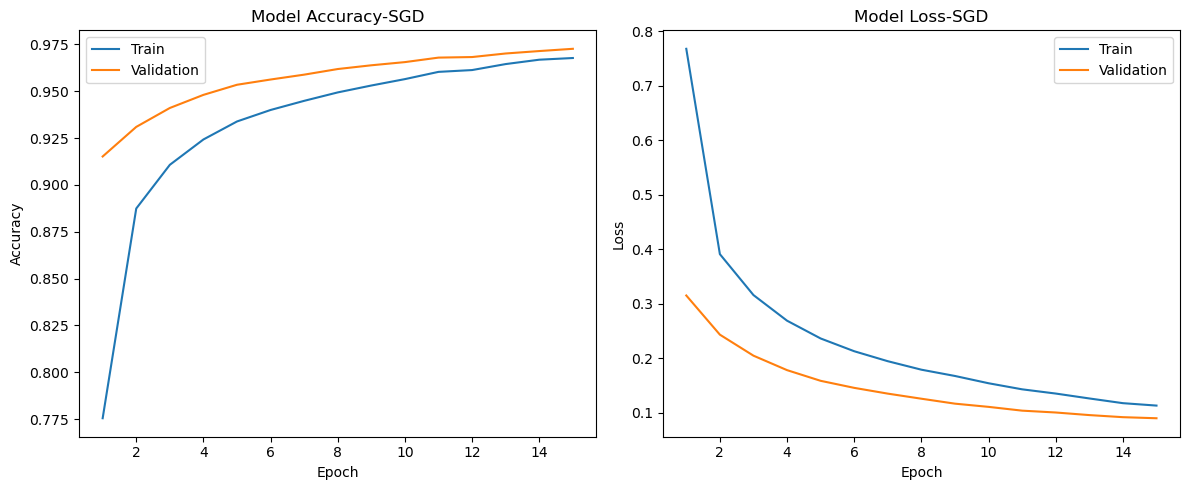

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


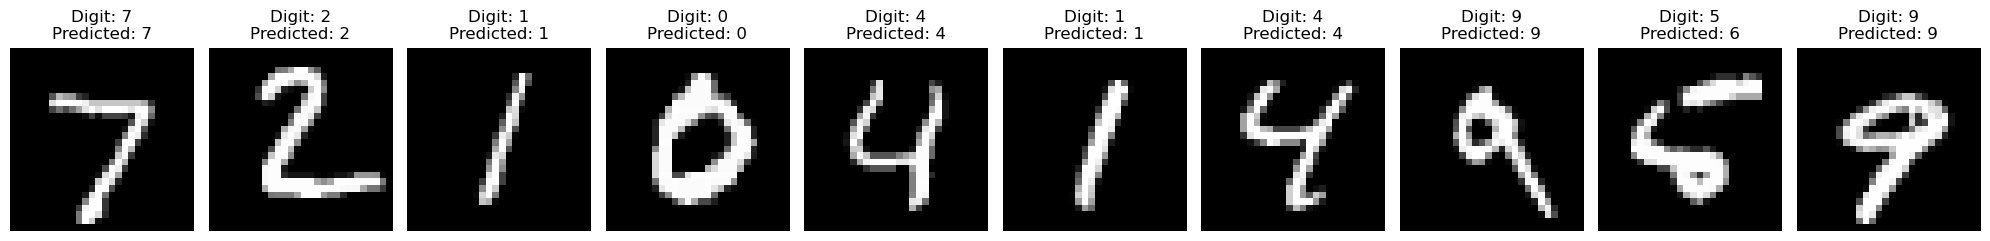

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9773 - loss: 0.0731

Test loss: 0.06256170570850372
Test accuracy: 0.980400025844574


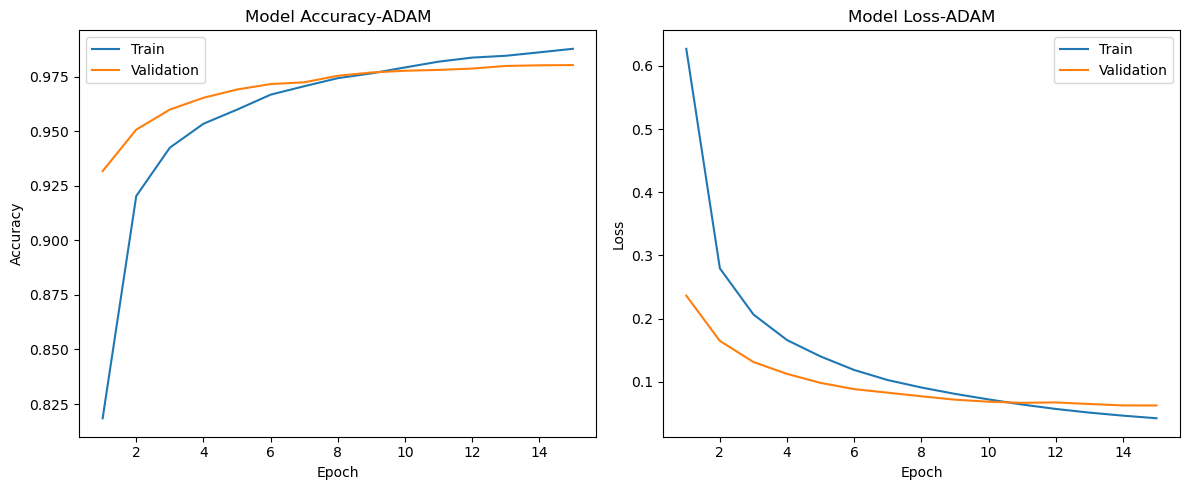

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


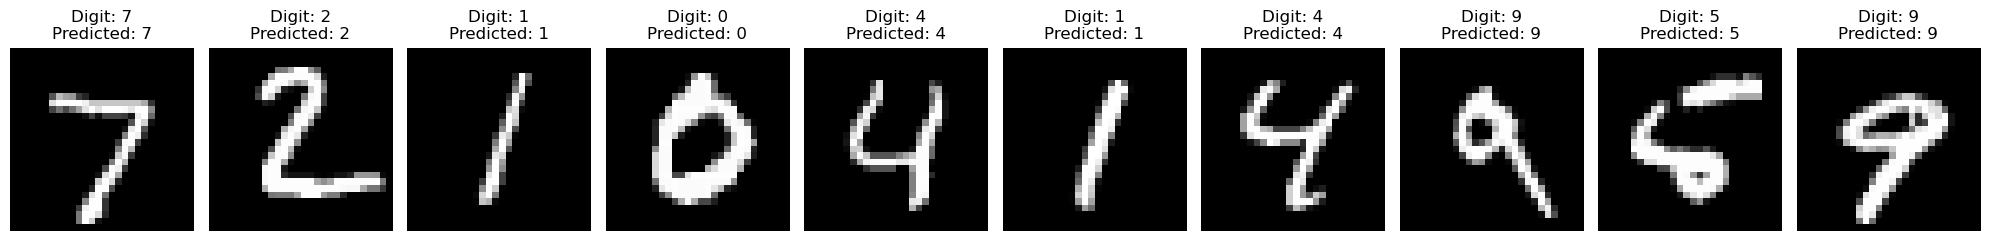

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9217 - loss: 0.2668

Test loss: 0.2276548147201538
Test accuracy: 0.9343000054359436


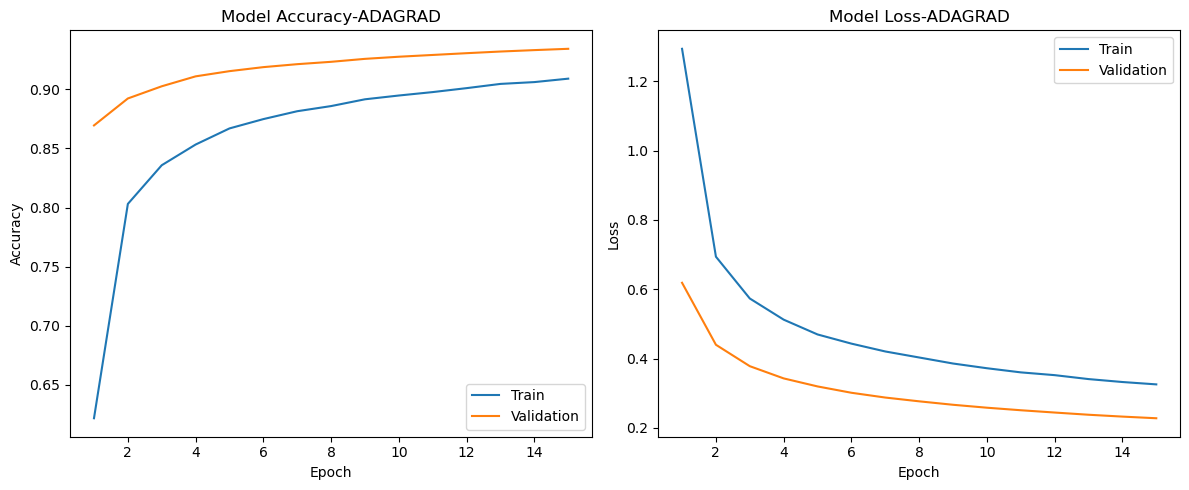

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


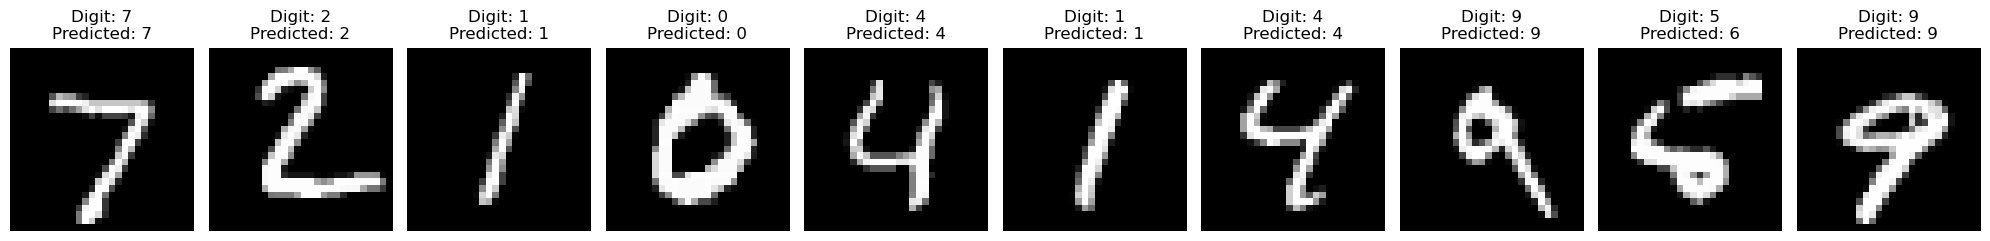

In [29]:
print("Training completed for SGD, Adam and Adagrad")
optimazers=['SGD','ADAM','ADAGRAD']
for model,history,opt in zip(models_DNN,histories_DNN,optimazers):
    plot_training_history_and_predictions(history, model, x_test, y_test, img_rows, img_cols,opt)


 



- **SGD (Stochastic Gradient Descent)**  
  Training starts slower, but accuracy improves steadily.  
  After ~15 epochs both training and validation accuracy exceed 97%.  
  At the beginning, validation accuracy is higher than training due to **Dropout** (active only in training).  
  This crossing is more visible here because SGD learns more slowly, but the two curves eventually converge, showing good generalization.  

  
- **Adam**  
  Shows the fastest convergence among the three.  
  After ~15 epochs, training and validation accuracy are around 98%, with low loss.  
  Like with SGD, in the first epochs validation accuracy is above training (dropout effect),  
  but Adam compensates quickly: training catches up and slightly surpasses validation, without strong overfitting.  
  The net is able to recognize the number five plotted , that have drawn strange  

- **Adagrad**  
  Faster improvement in the first epochs, but the accuracy saturates earlier.  
  Validation accuracy stabilizes around ~93–94%, lower than SGD and Adam.  
  The adaptive learning rate becomes too small over time, limiting further progress.  
  

Adam achieves the highest accuracy (~98%) in the shortest time thanks to its adaptive learning rate and momentum.  
SGD also reaches very good accuracy (~97–98%) but needs more epochs to converge, and doesn't predict all the number plotted.  
Adagrad improves quickly at first but its learning rate shrinks too much, causing early saturation and leaving final accuracy lower (~93–94%).  
  


# CNN

## Introduction to Convolutional Neural Networks (CNNs)

Until now we have treated each MNIST digit as a long 1D vector of 784 pixels.  
However, an image is not just a collection of independent numbers: pixels have **spatial correlations** with their neighbors, and digits preserve their shape even if slightly shifted within the frame.  

Convolutional Neural Networks (CNNs) are designed to exploit these properties.  

## CNN structure

- **Convolutional layers**  
  These layers apply learnable filters (small matrices) that slide across the image.  
  Each filter detects local patterns such as edges, corners, or small shapes, and creates a feature map highlighting where that pattern appears.  

- **Pooling layers**  
  After convolution, pooling reduces the spatial size of the feature maps, typically by taking the maximum value in each region (MaxPooling2D).  
  This keeps the most important information, reduces parameters, and makes the network more robust to small shifts in the input.  

- **Dropout**  
  During training, dropout randomly deactivates some neurons.  
  This prevents the network from relying too much on specific connections, improving generalization and reducing overfitting.  

- **Flatten + Dense layers**  
  After several convolution + pooling blocks, the feature maps are flattened into a 1D vector.  
  This vector is then fed into a standard **DNN** (dense layers) that combines the extracted features and outputs the final classification with a softmax layer.  

 In practice, a CNN first acts as an **automatic feature extractor** (with convolution and pooling), and then attaches a **DNN classifier** on top to make the final decision.  


## Why a CNN is better than a DNN for image recognition (MNIST)

- **Preserves spatial structure**:  
  CNNs process images as 2D matrices, capturing local patterns (edges, curves).  
  DNNs flatten images into 1D vectors, losing spatial relationships.  

- **Fewer parameters**:  
  Convolutions share weights across the image → fewer parameters, less risk of overfitting.  
  DNNs require a huge number of weights in the first dense layer.  

- **Translation invariance**:  
  CNNs naturally recognize digits even if slightly shifted.  
  DNNs are sensitive to pixel positions.  

 CNNs are more efficient, more robust, and achieve higher accuracy for image tasks like digit recognition.  


#### Creating Convolutional Neural Nets with Keras

We have so far considered each MNIST data sample as a $(28\times 28,)$-long 1d vector. On the other hand, we do know that in every one of the hand-written digits there are *local* spatial correlations between the pixels, but also *translational invariance*, which we would like to take advantage of to improve the accuracy of our classification model. To this end, we first need to reshape the training and test input data as follows

In [2]:

# reshape data, depending on Keras backend
if keras.backend.image_data_format() == 'channels_first':
    X_train = X_train.reshape(X_train.shape[0], 1, img_rows, img_cols)
    X_test = X_test.reshape(X_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)
    
print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
print()
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train shape: (60000, 28, 28, 1)
Y_train shape: (60000, 10)

60000 train samples
10000 test samples


In [3]:

from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation

def create_CNN():  # Aggiunti parametri alla funzione
    model = Sequential([
        # Blocco convoluzionale 1
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape), # 32 filters 3x3->output shape (28,28,32)
        MaxPooling2D((2, 2)),# output-> (14,14,32)
        Dropout(0.25),
        
        # Blocco convoluzionale 2
        Conv2D(64, (3, 3), activation='relu', padding='same'), #64 filters 3x3->output shape(14,14,64)
        MaxPooling2D((2, 2)),#output->(7,7,64)
        Dropout(0.25),
        
        # Classificatore
        Flatten(),# tranforms the tensor (7,7,64) in an array with 7x7x64=3136 components
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='Adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [4]:
# training parameters
batch_size = 32
epochs = 10

# create the deep conv net
model_CNN=create_CNN()

# train CNN
history_CNN=model_CNN.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True,
          verbose=1,
          validation_data=(X_test, Y_test))

print('Evaluation: ')
# evaluate model
score = model_CNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

/Users/pietro34/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 91s 47ms/step - accuracy: 0.8505 - loss: 0.4769 - val_accuracy: 0.9846 - val_loss: 0.0478
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 45ms/step - accuracy: 0.9684 - loss: 0.1062 - val_accuracy: 0.9868 - val_loss: 0.0377
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 45ms/step - accuracy: 0.9754 - loss: 0.0839 - val_accuracy: 0.9898 - val_loss: 0.0316
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 45ms/step - accuracy: 0.9804 - loss: 0.0683 - val_accuracy: 0.9911 - val_loss: 0.0269
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.9825 - loss: 0.0589 - val_accuracy: 0.9913 - val_loss: 0.0262
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 46ms/step - accuracy: 0.9834 - loss: 0.0555 - val_accuracy: 0.9920 - val_loss: 0.0262
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.9854 - loss: 0.0470 - val_accuracy: 0.9911 - val_loss: 0.0267
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 140s 43ms/step - accuracy: 0.9852 

In [8]:
import matplotlib.pyplot as plt


def plot_cnn(history, model, X_test, Y_test, img_rows=28, img_cols=28):
    # --- plot training history ---
    acc = history.history.get('accuracy') or history.history.get('acc')
    val_acc = history.history.get('val_accuracy') or history.history.get('val_acc')
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].plot(epochs, acc,  label='Train acc')
    axs[0].plot(epochs, val_acc,  label='Val acc')
    axs[0].set_title('Model Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend()

    axs[1].plot(epochs, loss,  label='Train loss')
    axs[1].plot(epochs, val_loss,  label='Val loss')
    axs[1].set_title('Model Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # --- plot predictions on test samples ---
    predictions = model.predict(X_test)

    plt.figure(figsize=(20, 5))
    for i in range(20):
        plt.subplot(2, 10, i + 1)
        plt.imshow(X_test[i, :, :, 0], cmap='gray')
        plt.title(f"Digit: {np.argmax(Y_test[i])}\nPred: {np.argmax(predictions[i])}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


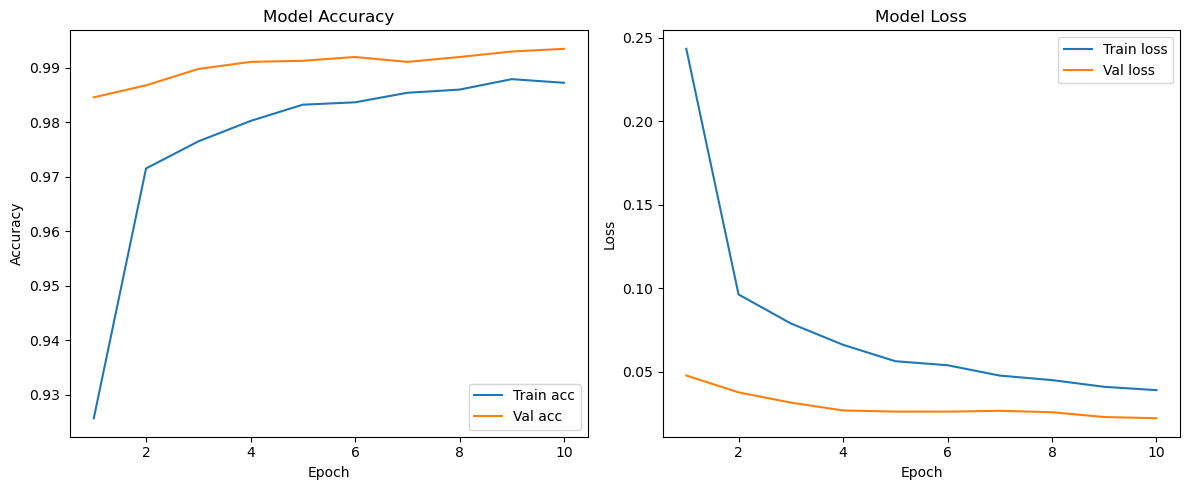

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


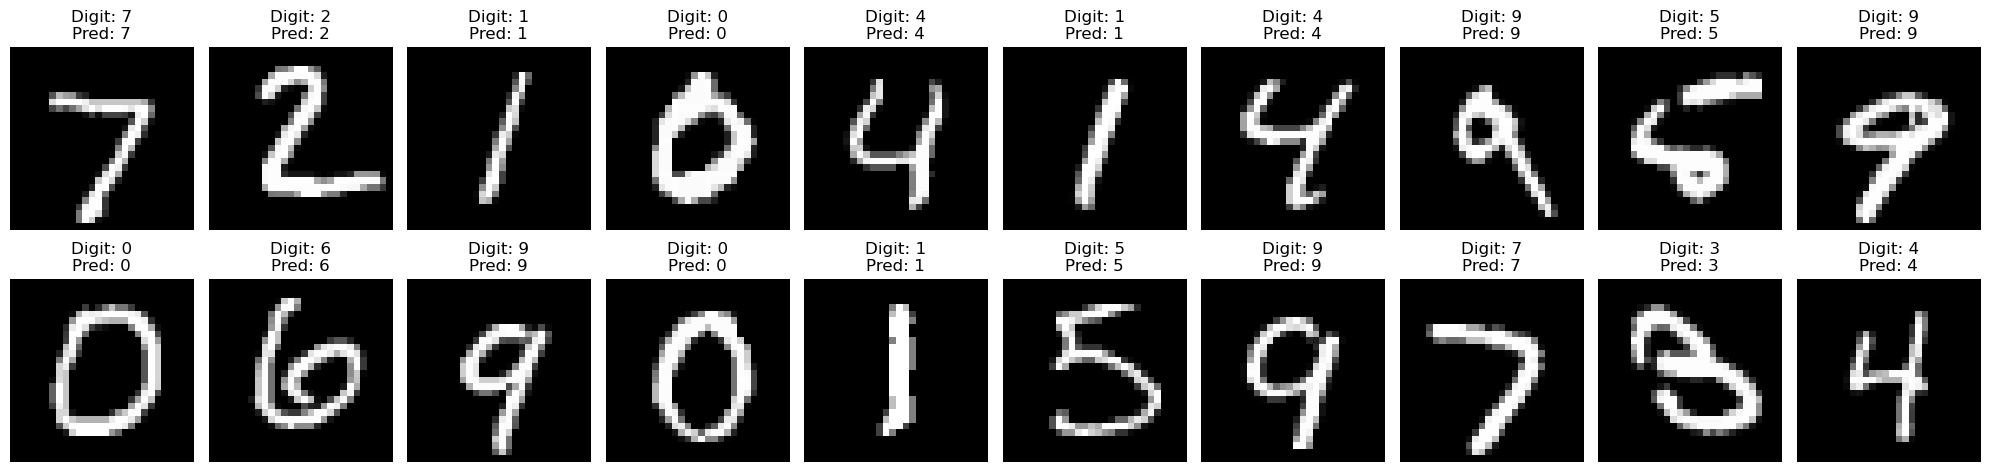

In [9]:
plot_cnn(history_CNN, model_CNN, X_test, Y_test)



The training and validation curves indicate that the CNN is learning effectively and generalizing well to unseen data.  
- **Accuracy**: Both training and validation accuracy increase steadily, with validation accuracy reaching over **99%** after 10 epochs. The validation accuracy is consistently slightly higher than the training accuracy, which suggests that dropout and other regularization techniques are working properly.  
- **Loss**: Both training and validation losses decrease, with validation loss remaining below the training loss. This behavior indicates stable convergence and no clear signs of overfitting.  

As an additional check, the model was used to predict the **first 20 digits of the MNIST test set** (not seen during training). All predictions were **correct**, further confirming the strong generalization ability of the network.




In addition to testing on the MNIST dataset, I created a set of **10 custom images** (one for each digit from **0 to 9**) using **GIMP**.  
- Each image was manually drawn and saved in grayscale format with a resolution of **28×28 pixels**, to match the input size expected by the CNN.  
- These custom images were then preprocessed (converted to grayscale, normalized, and reshaped) and fed into the trained CNN for prediction.  

This experiment allows me to check how well the network is able to recognize digits that were **not part of the MNIST dataset**, but instead generated independently by me.


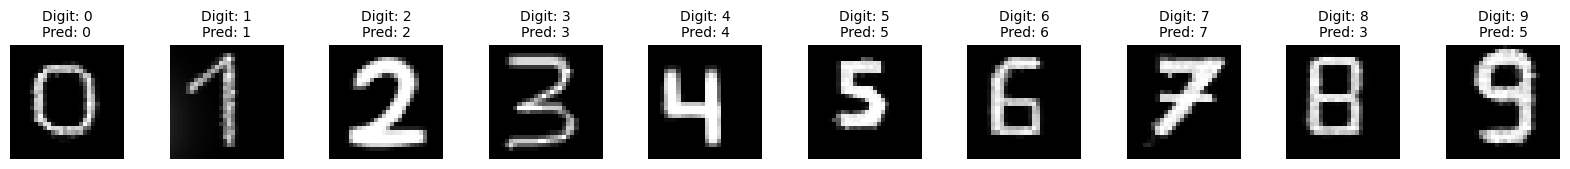

In [13]:

from PIL import Image
import os

# Lista dei file da processare
file_list = [ "0.png","1.png", "2.png", "3.png", "4.png", "5.png", "6.png", "7.png", "8.png", "9.png"]   

# Crea una singola riga con tutte le immagini
fig, axes = plt.subplots(1, len(file_list), figsize=(20, 4))  # 1 riga, N colonne
plt.subplots_adjust(wspace=0.4)  # Regola lo spazio orizzontale tra le immagini

# Se c'è solo un'immagine, trasforma axes in una lista
if len(file_list) == 1:
    axes = [axes]

for idx, digit_filename in enumerate(file_list):
    try:
        # Caricamento e preprocessing
        digit_in = Image.open(f'numeri/{digit_filename}').convert('L')
        ydim, xdim = digit_in.size
        data = np.array(digit_in) / 255.0  # Conversione diretta a numpy + normalizzazione
        
        # Predizione
        input_data = data.reshape(1, xdim, ydim, 1)  # Preparazione per la CNN
        pred = model_CNN.predict(input_data, verbose=0)
        predicted_digit = np.argmax(pred)
        confidence = np.max(pred)
        
        # Visualizzazione
        axes[idx].imshow(data, cmap='gray')
        axes[idx].set_title(f"Digit: {digit_filename.split('.')[0]}\nPred: {predicted_digit}", 
                          fontsize=10)
        axes[idx].axis('off')
        
    except Exception as e:
        print(f"Error processing {digit_filename}: {str(e)}")
        axes[idx].axis('off')

plt.show()


The CNN was tested on the 10 custom images (digits 0–9) generated with GIMP.  
The network correctly recognized most digits, but two misclassifications occurred:

- **Digit 8 → Predicted as 3**  
  The digit "8" was not recognized correctly. A possible reason is that the style of the custom "8" differs significantly from the ones in MNIST (for example, line thickness or how the two loops are connected). This could cause the network to confuse it with a "3", which shares similar curved features.

- **Digit 9 → Predicted as 5**  
  The custom "9" was predicted as "5". A plausible explanation is that the MNIST dataset typically represents the digit "9" without the lower “tail/gambetta”. Since the custom version includes this small extension, the CNN might fail to associate it with the MNIST-style "9", leading to confusion with "5".  

Overall, the experiment shows that while the CNN generalizes well to digits resembling MNIST, its performance drops when facing digit styles that deviate from the training distribution.
